In [24]:
import os, sys
notebook_dir = os.path.dirname(os.path.abspath('__file__' if '__file__' in dir() else '.'))
sys.path.insert(0, notebook_dir)

In [25]:
import os, sys
print("CWD:", os.getcwd())
print("nrtl_ternary.py exists here:", os.path.exists('nrtl_ternary.py'))
print(sys.path[:3])

CWD: /Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/Experiment-data-processing/NRTL-modelling
nrtl_ternary.py exists here: True
['/Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/Experiment-data-processing', '/Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/Experiment-data-processing', '/Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/Experiment-data-processing']


In [26]:
import sys
!{sys.executable} -m pip install numpy matplotlib mpltern ipywidgets pandas scipy coolprop ternary -q

In [27]:
import importlib
import nrtl_ternary
importlib.reload(nrtl_ternary)
from nrtl_ternary import NRTLTernary, build_tau

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import mpltern
from ipywidgets import interact, FloatSlider, Dropdown
from nrtl_ternary import NRTLTernary, build_tau


In [29]:
import importlib, nrtl_ternary
importlib.reload(nrtl_ternary)
from nrtl_ternary import NRTLTernary, build_tau

In [16]:
x0 = np.array([5.0, 8.0, -3.0, 3.0, -5.0, -3.0,
               -1000., -2000., 800., -800., 1500., 1000.])
model = NRTLTernary.from_csv('data/nrtl-data.csv', x0=x0)

/Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/.venv/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


seed=    42  MSE=8.1249e+00
seed=   123  MSE=8.3036e+00
seed=   777  MSE=8.2383e+00
seed=  1337  MSE=8.2383e+00
seed=  9999  MSE=8.8524e+00

Лучший MSE: 8.1249e+00


In [18]:
import pandas as pd

In [19]:
df = pd.read_csv('data/nrtl-data.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()
df['T'] = df['T'] + 273.15
df = df[df['gamma3'] > 0].reset_index(drop=True)

print(df[['x1','x2','x3','gamma1','gamma2','gamma3','T']].to_string())

         x1       x2       x3  gamma1  gamma2  gamma3       T
0   0.14041  0.22637  0.63322   3.315   2.552   1.597  330.07
1   0.29089  0.36965  0.33946   4.614   1.531   2.344  330.07
2   0.30405  0.47751  0.21844   4.598   1.100   3.696  330.04
3   0.05456  0.51307  0.43237  23.360   0.953   1.953  330.32
4   0.19707  0.54827  0.25467   8.866   0.965   1.542  336.02
5   0.33934  0.48860  0.17206   2.662   1.245   5.136  330.04
6   0.34057  0.14258  0.51685   2.453   3.542   1.813  330.49
7   0.65303  0.05042  0.29655   1.873   4.704   3.032  332.34
8   0.10215  0.04501  0.85284   7.618   9.332   1.142  331.01
9   0.64364  0.23040  0.12596   2.204   2.205   6.259  330.45
10  0.87117  0.08399  0.04484   0.763   3.932   3.014  357.45
11  0.96938  0.01935  0.01127   0.913   2.024   1.078  373.50
12  0.32763  0.60287  0.06949   1.940   1.139   0.173  351.94
13  0.44164  0.15320  0.40516   2.795   4.007   1.883  330.62
14  0.71558  0.13664  0.14777   1.148   1.425   0.976  359.48
15  0.45

In [31]:
from nrtl import nrtl, bubbleP_nrtl
pairs = [(0,1),(0,2),(1,0),(1,2),(2,0),(2,1)]

tau_params = model.params
alpha = model.alpha

for _, row in df.iterrows():
    T = row['T']
    x = np.array([row['x1'], row['x2'], row['x3']])
    gamma_exp = np.array([row['gamma1'], row['gamma2'], row['gamma3']])
    
    tau = build_tau(tau_params, T)
    gamma_calc = nrtl(alpha, tau, T, x)
    gamma_calc = np.clip(gamma_calc, 1e-10, None)
    
    err = np.sum((np.log(gamma_calc) - np.log(gamma_exp))**2)
    print(f"T={T:.1f}  err={err:.3f}  "
          f"γ_exp={gamma_exp.round(3)}  "
          f"γ_calc={gamma_calc.round(3)}")

T=330.1  err=0.858  γ_exp=[3.315 2.552 1.597]  γ_calc=[7.056 1.521 1.389]
T=330.1  err=0.072  γ_exp=[4.614 1.531 2.344]  γ_calc=[4.277 1.394 1.844]
T=330.0  err=0.469  γ_exp=[4.598 1.1   3.696]  γ_calc=[3.936 1.404 1.987]
T=330.3  err=0.446  γ_exp=[23.36   0.953  1.953]  γ_calc=[12.805  1.084  1.504]
T=336.0  err=0.355  γ_exp=[8.866 0.965 1.542]  γ_calc=[5.148 1.195 1.372]
T=330.0  err=0.839  γ_exp=[2.662 1.245 5.136]  γ_calc=[3.374 1.503 2.164]
T=330.5  err=0.257  γ_exp=[2.453 3.542 1.813]  γ_calc=[3.476 2.537 1.554]
T=332.3  err=0.036  γ_exp=[1.873 4.704 3.032]  γ_calc=[1.65  4.137 3.216]
T=331.0  err=0.280  γ_exp=[7.618 9.332 1.142]  γ_calc=[ 4.576 10.761  1.139]
T=330.4  err=0.233  γ_exp=[2.204 2.205 6.259]  γ_calc=[1.504 2.943 5.896]
T=357.4  err=0.131  γ_exp=[0.763 3.932 3.014]  γ_calc=[1.043 3.287 2.934]
T=373.5  err=0.147  γ_exp=[0.913 2.024 1.078]  γ_calc=[1.002 2.781 1.308]
T=351.9  err=0.794  γ_exp=[1.94  1.139 0.173]  γ_calc=[2.214 1.587 0.391]
T=330.6  err=0.234  γ_exp=[2.

In [34]:
df_clean = df.drop(index=[3, 12]).reset_index(drop=True)

In [ ]:
df_clean = df.drop(index=[3, 12]).reset_index(drop=True)
model = NRTLTernary.from_df(df_clean)

/Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/.venv/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


seed=    42  MSE=6.2562e+00
seed=   123  MSE=4.9855e+00
seed=   777  MSE=6.2562e+00
seed=  1337  MSE=4.9855e+00
seed=  9999  MSE=4.9855e+00

Лучший MSE: 4.9855e+00


In [35]:
pairs = [(0,1),(0,2),(1,0),(1,2),(2,0),(2,1)]
tau_params = model.params
alpha = model.alpha

for _, row in df_clean.iterrows():
    T = row['T']
    x = np.array([row['x1'], row['x2'], row['x3']])
    gamma_exp = np.array([row['gamma1'], row['gamma2'], row['gamma3']])
    tau = build_tau(tau_params, T)
    gamma_calc = nrtl(alpha, tau, T, x)
    gamma_calc = np.clip(gamma_calc, 1e-10, None)
    err = np.sum((np.log(gamma_calc) - np.log(gamma_exp))**2)
    print(f"T={T:.1f}  err={err:.3f}  γ_exp={gamma_exp.round(3)}  γ_calc={gamma_calc.round(3)}")

T=330.1  err=0.858  γ_exp=[3.315 2.552 1.597]  γ_calc=[7.056 1.521 1.389]
T=330.1  err=0.072  γ_exp=[4.614 1.531 2.344]  γ_calc=[4.277 1.394 1.844]
T=330.0  err=0.469  γ_exp=[4.598 1.1   3.696]  γ_calc=[3.936 1.404 1.987]
T=336.0  err=0.355  γ_exp=[8.866 0.965 1.542]  γ_calc=[5.148 1.195 1.372]
T=330.0  err=0.839  γ_exp=[2.662 1.245 5.136]  γ_calc=[3.374 1.503 2.164]
T=330.5  err=0.257  γ_exp=[2.453 3.542 1.813]  γ_calc=[3.476 2.537 1.554]
T=332.3  err=0.036  γ_exp=[1.873 4.704 3.032]  γ_calc=[1.65  4.137 3.216]
T=331.0  err=0.280  γ_exp=[7.618 9.332 1.142]  γ_calc=[ 4.576 10.761  1.139]
T=330.4  err=0.233  γ_exp=[2.204 2.205 6.259]  γ_calc=[1.504 2.943 5.896]
T=357.4  err=0.131  γ_exp=[0.763 3.932 3.014]  γ_calc=[1.043 3.287 2.934]
T=373.5  err=0.147  γ_exp=[0.913 2.024 1.078]  γ_calc=[1.002 2.781 1.308]
T=330.6  err=0.234  γ_exp=[2.795 4.007 1.883]  γ_calc=[2.641 2.484 1.968]
T=359.5  err=0.218  γ_exp=[1.148 1.425 0.976]  γ_calc=[1.194 1.791 1.463]
T=331.1  err=1.351  γ_exp=[4.947 1.

In [37]:
df_clean2 = df_clean.drop(index=[13, 14]).reset_index(drop=True)

In [39]:
model2 = NRTLTernary.from_df(df_clean2)

/Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/.venv/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
Process SpawnPoolWorker-60:
Process SpawnPoolWorker-52:
Process SpawnPoolWorker-58:
Process SpawnPoolWorker-56:
Process SpawnPoolWorker-57:
Process SpawnPoolWorker-55:
Process SpawnPoolWorker-51:
Process SpawnPoolWorker-53:
Process SpawnPoolWorker-54:
Process SpawnPoolWorker-59:


KeyboardInterrupt: 

In [38]:
for _, row in df_clean2.iterrows():
    T = row['T']
    x = np.array([row['x1'], row['x2'], row['x3']])
    gamma_exp = np.array([row['gamma1'], row['gamma2'], row['gamma3']])
    tau = build_tau(model2.params, T)
    gamma_calc = nrtl(model2.alpha, tau, T, x)
    gamma_calc = np.clip(gamma_calc, 1e-10, None)
    err = np.sum((np.log(gamma_calc) - np.log(gamma_exp))**2)
    print(f"T={T:.1f}  err={err:.3f}  γ_exp={gamma_exp.round(3)}  γ_calc={gamma_calc.round(3)}")

NameError: name 'model2' is not defined

In [40]:
df_clean3 = df_clean2.drop(index=[3]).reset_index(drop=True)


In [41]:
model3 = NRTLTernary.from_df(df_clean3)

/Users/iurii/Documents/mipt/2sem/labs/project/Project-Labs-S26S/.venv/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


seed=    42  MSE=1.4416e+00
seed=   123  MSE=1.4416e+00
seed=   777  MSE=1.4416e+00
seed=  1337  MSE=1.4416e+00
seed=  9999  MSE=1.4416e+00

Лучший MSE: 1.4416e+00


In [42]:
for _, row in df_clean3.iterrows():
    T = row['T']
    x = np.array([row['x1'], row['x2'], row['x3']])
    gamma_exp = np.array([row['gamma1'], row['gamma2'], row['gamma3']])
    tau = build_tau(model3.params, T)
    gamma_calc = nrtl(model3.alpha, tau, T, x)
    gamma_calc = np.clip(gamma_calc, 1e-10, None)
    err = np.sum((np.log(gamma_calc) - np.log(gamma_exp))**2)
    print(f"T={T:.1f}  err={err:.3f}  γ_exp={gamma_exp.round(3)}  γ_calc={gamma_calc.round(3)}")

T=330.1  err=0.206  γ_exp=[3.315 2.552 1.597]  γ_calc=[4.878 2.994 1.339]
T=330.1  err=0.087  γ_exp=[4.614 1.531 2.344]  γ_calc=[3.466 1.446 2.448]
T=330.0  err=0.111  γ_exp=[4.598 1.1   3.696]  γ_calc=[3.315 1.163 3.57 ]
T=330.0  err=0.082  γ_exp=[2.662 1.245 5.136]  γ_calc=[3.144 1.134 4.147]
T=330.5  err=0.159  γ_exp=[2.453 3.542 1.813]  γ_calc=[3.439 3.46  1.468]
T=332.3  err=0.094  γ_exp=[1.873 4.704 3.032]  γ_calc=[1.691 6.269 2.934]
T=331.0  err=0.058  γ_exp=[7.618 9.332 1.142]  γ_calc=[6.143 9.547 1.029]
T=330.4  err=0.064  γ_exp=[2.204 2.205 6.259]  γ_calc=[1.769 2.363 5.653]
T=357.4  err=0.183  γ_exp=[0.763 3.932 3.014]  γ_calc=[1.066 3.137 2.62 ]
T=373.5  err=0.022  γ_exp=[0.913 2.024 1.078]  γ_calc=[1.003 2.22  1.153]
T=330.6  err=0.088  γ_exp=[2.795 4.007 1.883]  γ_calc=[2.718 2.983 1.872]
T=359.5  err=0.175  γ_exp=[1.148 1.425 0.976]  γ_calc=[1.214 1.534 1.468]
T=330.2  err=0.114  γ_exp=[3.453 1.537 3.449]  γ_calc=[2.475 1.618 3.396]


In [107]:
def make_ternary_grid(T, n=30):
    pts = []
    for i in range(n + 1):
        for j in range(n + 1 - i):
            k = n - i - j
            pts.append((i / n, j / n, k / n))
    pts = np.array(pts)
    gammas = np.array([model.get_gamma(T, *p) for p in pts])
    return pts[:, 0], pts[:, 1], pts[:, 2], gammas

In [108]:
print(model3.get_gamma(330, 0.001, 0.001, 0.998))
# чистая вода: gamma воды должна быть ~1
print(model3.get_gamma(330, 0.998, 0.001, 0.001))

[ 8.33432916 18.1420587   1.00000722]
[  1.00003352 100.15958296  76.58283604]


In [109]:
def plot_ternary_heatmap(T=298.15, component='γ₁ (water)'):
    comp_map = {'γ₁ (water)': 0, 'γ₂ (ethanol)': 1, 'γ₃ (n-hexane)': 2}
    idx = comp_map[component]

    x1, x2, x3, gammas = make_ternary_grid(T, n=30)
    values = gammas[:, idx]

    # обрезаем выбросы
    vmin = np.percentile(values, 2)
    vmax = np.percentile(values, 95)
    values_clipped = np.clip(values, vmin, vmax)

    fig, ax = plt.subplots(
        figsize=(6, 5),
        subplot_kw=dict(projection='ternary')
    )

    cs = ax.tripcolor(x1, x2, x3, values_clipped,
                      cmap='RdYlBu_r', shading='gouraud',
                      vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(cs, ax=ax, pad=0.1)
    cbar.set_label(component, fontsize=11)

    ax.set_tlabel(COMPONENTS[0], fontsize=11)
    ax.set_llabel(COMPONENTS[1], fontsize=11)
    ax.set_rlabel(COMPONENTS[2], fontsize=11)
    ax.taxis.set_label_position('tick1')
    ax.laxis.set_label_position('tick1')
    ax.raxis.set_label_position('tick1')

    ax.set_title(f'{component}  |  T = {T:.1f} K', pad=12)
    plt.tight_layout()
    plt.show()


In [ ]:
COMPONENTS = ['water', 'ethanol', 'n-hexane']
interact(
    plot_ternary_heatmap,
    T=FloatSlider(value=298.15, min=280, max=400, step=5,
                  description='T (K)', continuous_update=False),
    component=Dropdown(
        options=['γ₁ (water)', 'γ₂ (ethanol)', 'γ₃ (n-hexane)'],
        value='γ₁ (water)',
        description='Component'
    )
);


interactive(children=(FloatSlider(value=298.15, continuous_update=False, description='T (K)', max=400.0, min=2…

In [47]:
def get_Psat(T):
    return np.array([
        PropsSI('P', 'T', T, 'Q', 0, 'Water'),
        PropsSI('P', 'T', T, 'Q', 0, 'Ethanol'),
        PropsSI('P', 'T', T, 'Q', 0, 'Hexane'),
    ])

In [50]:
from CoolProp.CoolProp import PropsSI
T = 330.07
Psat = get_Psat(T)
tau = build_tau(model3.params, T)

x = np.array([0.2, 0.3, 0.5])
P_guess = np.sum(x * Psat)
result = bubbleP_nrtl(P_guess, x.copy(), Psat, model3.alpha, tau, T, x)
print(type(result), len(result))
print(result)

<class 'list'> 2
[array([97106.66791442]), array([0.14852964, 0.25078265, 0.60068771])]


xL=[0.14041 0.22637 0.63322]  P=92798.96  xV=[0.121  0.2818 0.5972]  sum=1.0000
xL=[0.29089 0.36965 0.33946]  P=92798.96  xV=[0.1807 0.2255 0.5938]  sum=1.0000
xL=[0.30405 0.47751 0.21844]  P=92798.96  xV=[0.1858 0.2409 0.5733]  sum=1.0000
xL=[0.19707 0.54827 0.25467]  P=92798.96  xV=[0.1383 0.3128 0.5489]  sum=1.0000
xL=[0.33934 0.4886  0.17206]  P=92798.96  xV=[0.2045 0.25   0.5456]  sum=1.0000
xL=[0.34057 0.14258 0.51685]  P=92798.96  xV=[0.2193 0.2173 0.5634]  sum=1.0000
xL=[0.65303 0.05042 0.29655]  P=92798.96  xV=[0.2118 0.1422 0.646 ]  sum=1.0000
xL=[0.10215 0.04501 0.85284]  P=92798.96  xV=[0.1232 0.1984 0.6784]  sum=1.0000
xL=[0.64364 0.2304  0.12596]  P=92798.96  xV=[0.217  0.2442 0.5388]  sum=1.0000
xL=[0.87117 0.08399 0.04484]  P=92798.96  xV=[0.4991 0.32   0.1809]  sum=1.0000
xL=[0.96938 0.01935 0.01127]  P=92798.96  xV=[0.8849 0.0864 0.0286]  sum=1.0000
xL=[0.44164 0.1532  0.40516]  P=92798.96  xV=[0.2274 0.2037 0.5689]  sum=1.0000
xL=[0.71558 0.13664 0.14777]  P=92798.96

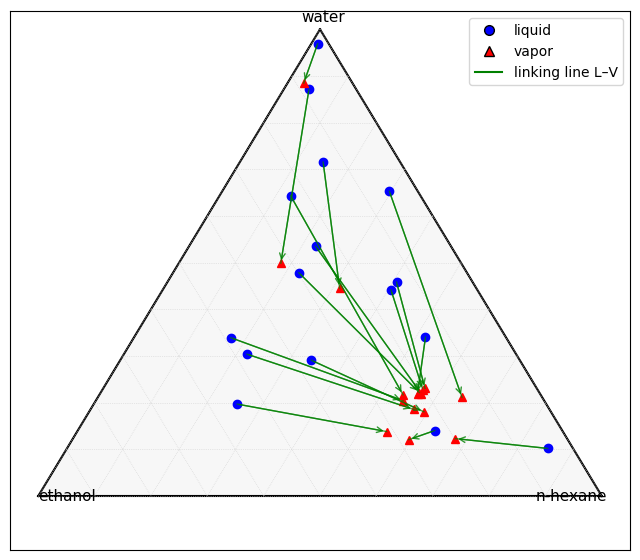

In [99]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
from nrtl import bubbleP_nrtl

T = 330.07
Psat = get_Psat(T)
tau  = build_tau(model3.params, T)

liquid_points = [
    (row['x1'], row['x2'], row['x3']) 
    for _, row in df_clean3.iterrows()
]
tau  = build_tau(model3.params, T)

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(8, 7)
tax.boundary()
tax.gridlines(multiple=0.1, color="lightgray", linewidth=0.5, ls=":")
tax.annotate("n-hexane", (1.01, 0, 0), ha="right",  va="center", fontsize=11)
tax.annotate("water",   (0, 1.01, 0), ha="center", va="bottom", fontsize=11)
tax.annotate("ethanol",  (0, 0, 1.01), ha="left",   va="center", fontsize=11)

ax = tax.get_axes()

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", **kwargs))

for _, row in df_clean.iterrows():
    x = np.array([row['x1'], row['x2'], row['x3']])
    T_row = row['T']
    Psat_row = get_Psat(T_row)
    tau_row  = build_tau(model3.params, T_row)
    P_guess = np.sum(x * Psat_row)
    result = bubbleP_nrtl(P_guess, x.copy(), Psat_row, model3.alpha, tau_row, T_row, x)
    xv      = result[1]

    pL = (x[2],  x[0],  x[1])
    pV = (xv[2], xv[0], xv[1])

    print(f"xL={x}  P={P_bub:.2f}  xV={xv.round(4)}  sum={xv.sum():.4f}")

    tax.plot([pL], marker="o", color="blue",  markersize=6)
    tax.plot([pV], marker="^", color="red",   markersize=6)
    tax.line(pL, pV, linewidth=1, color="green", alpha=0.7, marker=None)
    draw_arrow(pL, pV, color="green", linewidth=1, alpha=0.8)

legend_elements = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="blue",  markersize=7, label="liquid"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="red",   markersize=7, label="vapor"),
    Line2D([0],[0], color="green", lw=1.5, label="linking line L–V"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)
tax.clear_matplotlib_ticks()
plt.show()

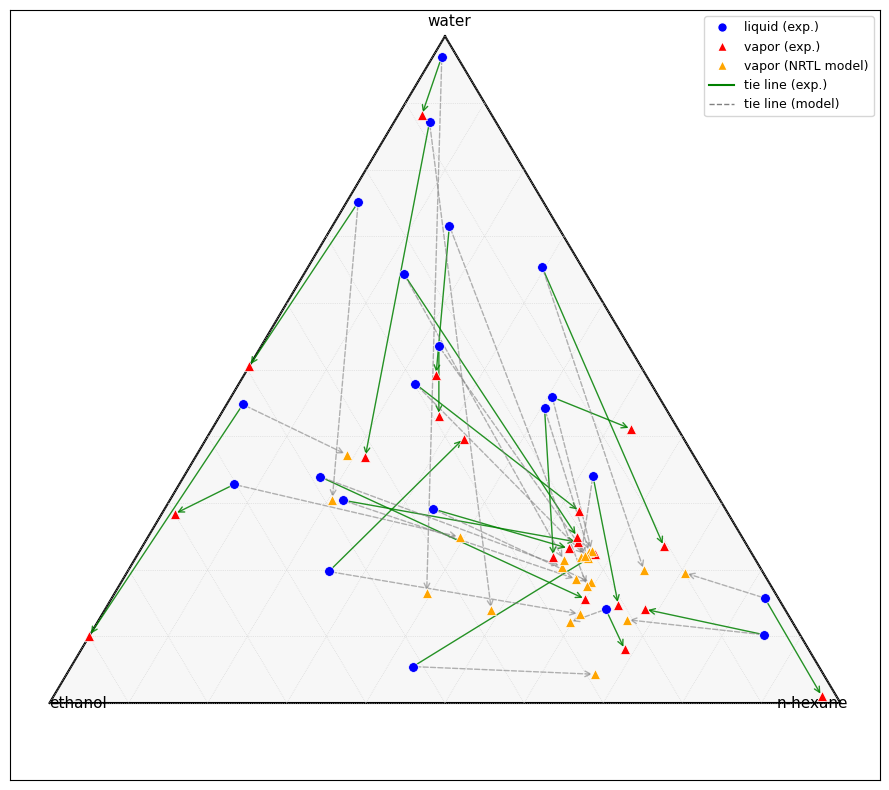

In [100]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
from nrtl import bubbleP_nrtl

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(9, 8)
tax.boundary()
tax.gridlines(multiple=0.1, color="lightgray", linewidth=0.5, ls=":")
tax.annotate("n-hexane", (1.01, 0, 0),    ha="right",  va="center", fontsize=11)
tax.annotate("water",    (0, 1.01, 0),    ha="center", va="bottom", fontsize=11)
tax.annotate("ethanol",  (0, 0, 1.01),    ha="left",   va="center", fontsize=11)

ax = tax.get_axes()

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", **kwargs))

# --- экспериментальные данные (из exp_xL, exp_xV) ---
for xL, xV in zip(exp_xL, exp_xV):
    pL = (xL[2], xL[0], xL[1])
    pV = (xV[2], xV[0], xV[1])
    tax.plot([pL], marker="o", color="blue",   markersize=7, zorder=4,
             markeredgecolor="white", markeredgewidth=0.5)
    tax.plot([pV], marker="^", color="red",    markersize=7, zorder=4,
             markeredgecolor="white", markeredgewidth=0.5)
    draw_arrow(pL, pV, color="green", linewidth=1.0, alpha=0.85)

# --- модельные данные (через bubbleP_nrtl по тем же жидким точкам) ---
for xL in exp_xL:
    x = xL.copy()
    T_row    = 330.07  # или row['T'] если есть
    Psat_row = get_Psat(T_row)
    tau_row  = build_tau(model3.params, T_row)
    P_guess  = np.sum(x * Psat_row)
    try:
        result = bubbleP_nrtl(P_guess, x.copy(), Psat_row,
                              model3.alpha, tau_row, T_row, x)
        xv = result[1]
        pL = (x[2],  x[0],  x[1])
        pV = (xv[2], xv[0], xv[1])
        tax.plot([pV], marker="^", color="orange", markersize=7, zorder=5,
                 markeredgecolor="white", markeredgewidth=0.5)
        draw_arrow(pL, pV, color="gray", linewidth=1.0, alpha=0.6,
                   linestyle="dashed")
    except Exception:
        pass

legend_elements = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="blue",
           markersize=7, markeredgecolor="white", label="liquid (exp.)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="red",
           markersize=7, markeredgecolor="white", label="vapor (exp.)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="orange",
           markersize=7, markeredgecolor="white", label="vapor (NRTL model)"),
    Line2D([0],[0], color="green", lw=1.5, label="tie line (exp.)"),
    Line2D([0],[0], color="gray",  lw=1.0, ls="--", label="tie line (model)"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=9)
tax.clear_matplotlib_ticks()
plt.tight_layout()
plt.show()

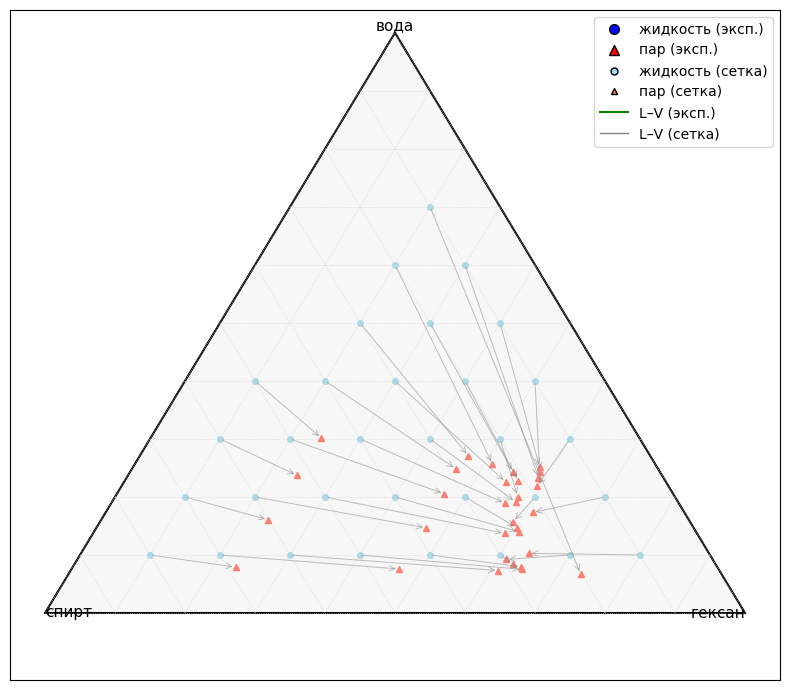

In [ ]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
from nrtl import bubbleP_nrtl, nrtl
from scipy.optimize import brentq

def bubbleT_nrtl(P, x, alpha, params):
    def residual(T):
        Psat = get_Psat(T)
        tau = build_tau(params, T)
        gamma = nrtl(alpha, tau, T, x)
        return np.sum(gamma * x * Psat) - P
    T_bub = brentq(residual, 280.0, 420.0)
    Psat = get_Psat(T_bub)
    tau = build_tau(params, T_bub)
    gamma = nrtl(alpha, tau, T_bub, x)
    xv = gamma * x * Psat / P
    xv = xv / xv.sum()
    return T_bub, xv

P_atm = 101325.0

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(8, 7)
tax.boundary()
tax.gridlines(multiple=0.1, color="lightgray", linewidth=0.5, ls=":")
tax.annotate("гексан", (1, 0, 0), ha="right",  va="center", fontsize=11)
tax.annotate("вода",   (0, 1, 0), ha="center", va="bottom", fontsize=11)
tax.annotate("спирт",  (0, 0, 1), ha="left",   va="center", fontsize=11)

ax = tax.get_axes()

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", **kwargs))

# сетка составов
grid_points = []
step = 0.1
for i in range(5):
    for j in range(5 - i):
        x1 = i * step
        x2 = j * step
        x3 = 1.0 - x1 - x2
        if x3 >= 0.01 and x1 >= 0.01 and x2 >= 0.01:
            grid_points.append((x1, x2, x3))

for x1, x2, x3 in grid_points:
    x = np.array([x1, x2, x3])
    try:
        T_bub, xv = bubbleT_nrtl(P_atm, x, model3.alpha, model3.params)
        pL = (x[2],  x[0],  x[1])
        pV = (xv[2], xv[0], xv[1])
        tax.plot([pL], marker="o", color="lightblue", markersize=4, zorder=2)
        tax.plot([pV], marker="^", color="salmon",    markersize=4, zorder=2)
        draw_arrow(pL, pV, color="gray", linewidth=0.7, alpha=0.5)
    except Exception:
        pass


legend_elements = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="blue",      markersize=7, label="жидкость (эксп.)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="red",       markersize=7, label="пар (эксп.)"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor="lightblue", markersize=5, label="жидкость (сетка)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="salmon",    markersize=5, label="пар (сетка)"),
    Line2D([0],[0], color="green", lw=1.5, label="L–V (эксп.)"),
    Line2D([0],[0], color="gray",  lw=1.0, label="L–V (сетка)"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)
tax.clear_matplotlib_ticks()
plt.tight_layout()
plt.show()

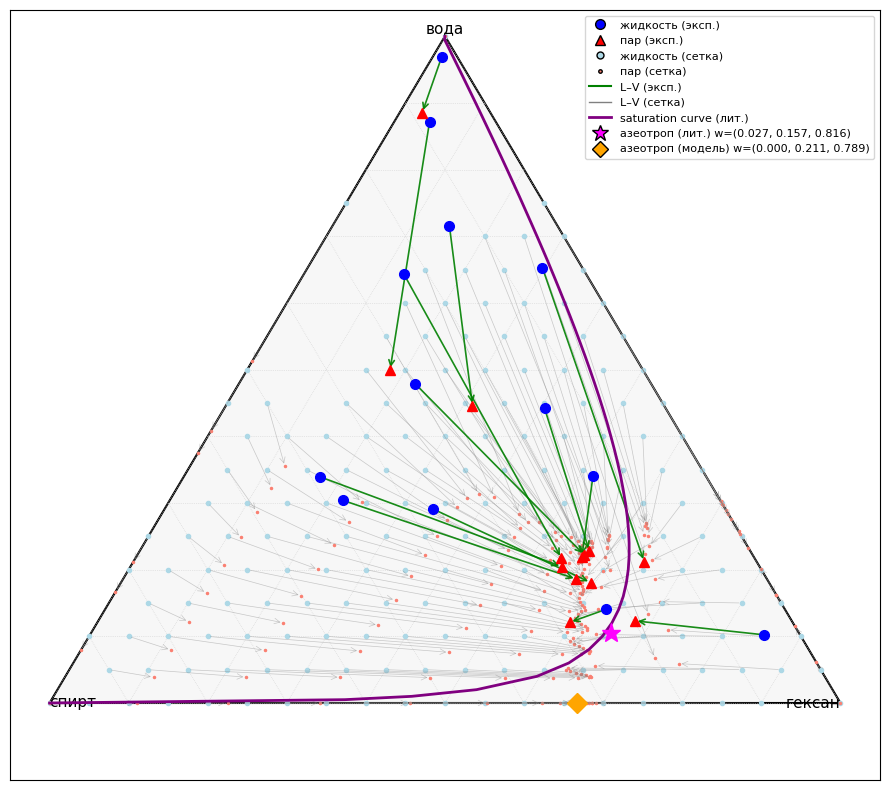

In [68]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
from nrtl import bubbleP_nrtl, nrtl
from scipy.optimize import brentq

MW = np.array([18.015, 46.069, 86.178])  # вода, этанол, гексан

def to_mass(x):
    w = x * MW
    return w / w.sum()

def bubbleT_nrtl(P, x, alpha, params):
    def residual(T):
        Psat = get_Psat(T)
        tau = build_tau(params, T)
        gamma = nrtl(alpha, tau, T, x)
        return np.sum(gamma * x * Psat) - P
    T_bub = brentq(residual, 280.0, 420.0)
    Psat = get_Psat(T_bub)
    tau = build_tau(params, T_bub)
    gamma = nrtl(alpha, tau, T_bub, x)
    xv = gamma * x * Psat / P
    xv = xv / xv.sum()
    return T_bub, xv

P_atm = 101325.0

# азеотроп из статьи (Gomis 2007): вода, этанол, гексан
x_az_lit = np.array([0.105, 0.236, 0.658])
w_az_lit  = to_mass(x_az_lit)

# азеотроп из модели
x_az_model = np.array([0.0, 0.3336, 0.6664])
w_az_model  = to_mass(x_az_model)

# saturation curve из Table 24 (x1=этанол, x2=гексан, x3=вода=1-x1-x2)
sat_table = [
    (0.0000, 2.3e-6), (0.3709, 0.0050), (0.4530, 0.0100), (0.5299, 0.0200),
    (0.5963, 0.0400), (0.6265, 0.0600), (0.6418, 0.0800), (0.6490, 0.1000),
    (0.6510, 0.1200), (0.6495, 0.1400), (0.6454, 0.1600), (0.6393, 0.1800),
    (0.6317, 0.2000), (0.6228, 0.2200), (0.6128, 0.2400), (0.6020, 0.2600),
    (0.5904, 0.2800), (0.5781, 0.3000), (0.5653, 0.3200), (0.5521, 0.3400),
    (0.5383, 0.3600), (0.5242, 0.3800), (0.5097, 0.4000), (0.4950, 0.4200),
    (0.4799, 0.4400), (0.4646, 0.4600), (0.4490, 0.4800), (0.4332, 0.5000),
    (0.4172, 0.5200), (0.4010, 0.5400), (0.3847, 0.5600), (0.3682, 0.5800),
    (0.3515, 0.6000), (0.3347, 0.6200), (0.3178, 0.6400), (0.3008, 0.6600),
    (0.2836, 0.6800), (0.2663, 0.7000), (0.2489, 0.7200), (0.2314, 0.7400),
    (0.2139, 0.7600), (0.1962, 0.7800), (0.1785, 0.8000), (0.1607, 0.8200),
    (0.1428, 0.8400), (0.1248, 0.8600), (0.1068, 0.8800), (0.0887, 0.9000),
    (0.0705, 0.9200), (0.0523, 0.9400), (0.0340, 0.9600), (0.0157, 0.9800),
    (0.0065, 0.9900), (0.0019, 0.9950), (0.0000, 0.99953),
]
# x1=этанол, x2=гексан → маппинг на треугольник (спирт, гексан, вода)
sat_curve_pts = []
for x_eth, x_hex in sat_table:
    x_wat = 1.0 - x_eth - x_hex
    if x_wat >= 0:
        sat_curve_pts.append((x_eth, x_hex, x_wat))  # спирт, гексан, вода

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(9, 8)
tax.boundary()
tax.gridlines(multiple=0.1, color="lightgray", linewidth=0.5, ls=":")
tax.annotate("гексан", (1, 0, 0), ha="right",  va="center", fontsize=11)
tax.annotate("вода",   (0, 1, 0), ha="center", va="bottom", fontsize=11)
tax.annotate("спирт",  (0, 0, 1), ha="left",   va="center", fontsize=11)

ax = tax.get_axes()

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", **kwargs))

# saturation curve из статьи
tax.plot(sat_curve_pts, linewidth=2, color="purple", marker=None, zorder=4, label="saturation curve (лит.)")

# сетка составов
grid_points = []
step = 0.05
for i in range(21):
    for j in range(21 - i):
        x1 = i * step
        x2 = j * step
        x3 = 1.0 - x1 - x2
        if x3 >= 0:
            grid_points.append((x1, x2, x3))

for x1, x2, x3 in grid_points:
    x = np.array([x1, x2, x3])
    try:
        T_bub, xv = bubbleT_nrtl(P_atm, x, model3.alpha, model3.params)
        pL = (x[2],  x[0],  x[1])
        pV = (xv[2], xv[0], xv[1])
        tax.plot([pL], marker="o", color="lightblue", markersize=3, zorder=2)
        tax.plot([pV], marker=".", color="salmon",    markersize=3, zorder=2)
        draw_arrow(pL, pV, color="gray", linewidth=0.5, alpha=0.4)
    except Exception:
        pass

# экспериментальные точки
for _, row in df_clean3.iterrows():
    x = np.array([row['x1'], row['x2'], row['x3']])
    T_row    = row['T']
    Psat_row = get_Psat(T_row)
    tau_row  = build_tau(model3.params, T_row)
    P_guess  = np.sum(x * Psat_row)
    try:
        result = bubbleP_nrtl(P_guess, x.copy(), Psat_row, model3.alpha, tau_row, T_row, x)
        xv = result[1]
        pL = (x[2],  x[0],  x[1])
        pV = (xv[2], xv[0], xv[1])
        tax.plot([pL], marker="o", color="blue",  markersize=7, zorder=5)
        tax.plot([pV], marker="^", color="red",   markersize=7, zorder=5)
        draw_arrow(pL, pV, color="green", linewidth=1.2, alpha=0.9)
    except Exception:
        pass

# азеотроп из литературы
p_az_lit = (x_az_lit[2], x_az_lit[0], x_az_lit[1])
tax.plot([p_az_lit], marker="*", color="magenta", markersize=14, zorder=6)

# азеотроп из модели
p_az_model = (x_az_model[2], x_az_model[0], x_az_model[1])
tax.plot([p_az_model], marker="D", color="orange", markersize=10, zorder=6)

w_az_lit_str   = f"w=({w_az_lit[0]:.3f}, {w_az_lit[1]:.3f}, {w_az_lit[2]:.3f})"
w_az_model_str = f"w=({w_az_model[0]:.3f}, {w_az_model[1]:.3f}, {w_az_model[2]:.3f})"

legend_elements = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="blue",      markersize=7,  label="жидкость (эксп.)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="red",       markersize=7,  label="пар (эксп.)"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor="lightblue", markersize=5,  label="жидкость (сетка)"),
    Line2D([0],[0], marker=".", color="none", markerfacecolor="salmon",    markersize=5,  label="пар (сетка)"),
    Line2D([0],[0], color="green",  lw=1.5, label="L–V (эксп.)"),
    Line2D([0],[0], color="gray",   lw=1.0, label="L–V (сетка)"),
    Line2D([0],[0], color="purple", lw=2.0, label="saturation curve (лит.)"),
    Line2D([0],[0], marker="*", color="none", markerfacecolor="magenta", markersize=12,
           label=f"азеотроп (лит.) {w_az_lit_str}"),
    Line2D([0],[0], marker="D", color="none", markerfacecolor="orange",  markersize=8,
           label=f"азеотроп (модель) {w_az_model_str}"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=8)
tax.clear_matplotlib_ticks()
plt.tight_layout()
plt.show()

In [70]:
vapor_points = []

for x1, x2, x3 in grid_points:
    x = np.array([x1, x2, x3])
    try:
        T_bub, xv = bubbleT_nrtl(P_atm, x, model3.alpha, model3.params)
        vapor_points.append(xv)
    except Exception:
        pass

vapor_points = np.array(vapor_points)
x_az_sink = vapor_points.mean(axis=0)
x_az_sink /= x_az_sink.sum()
print(f"Азеотроп (сток): x={x_az_sink.round(4)}")

Азеотроп (сток): x=[0.1666 0.3059 0.5275]


In [71]:
x_az_sink = np.median(vapor_points, axis=0)
x_az_sink /= x_az_sink.sum()
print(f"Азеотроп (медиана): x={x_az_sink.round(4)}")

Азеотроп (медиана): x=[0.1646 0.2648 0.5705]


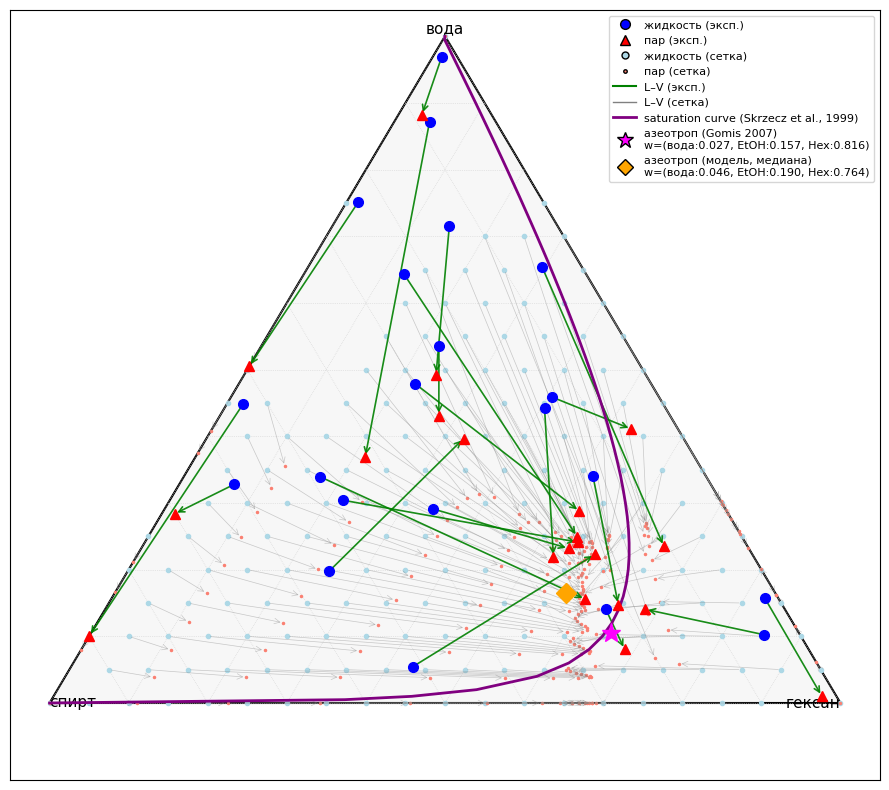

In [73]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
from nrtl import bubbleP_nrtl, nrtl
from scipy.optimize import brentq
import io

MW = np.array([18.015, 46.069, 86.178])  # вода, этанол, гексан

def to_mole(w):
    """массовые доли → мольные доли"""
    n = w / MW
    return n / n.sum()

def to_mass(x):
    """мольные доли → массовые доли"""
    w = x * MW
    return w / w.sum()

def bubbleT_nrtl(P, x, alpha, params):
    def residual(T):
        Psat = get_Psat(T)
        tau = build_tau(params, T)
        gamma = nrtl(alpha, tau, T, x)
        return np.sum(gamma * x * Psat) - P
    try:
        T_bub = brentq(residual, 280.0, 500.0)
    except ValueError:
        raise
    Psat = get_Psat(T_bub)
    tau = build_tau(params, T_bub)
    gamma = nrtl(alpha, tau, T_bub, x)
    xv = gamma * x * Psat / P
    xv = xv / xv.sum()
    return T_bub, xv

# экспериментальные данные в массовых долях (%)
# порядок: вода, спирт, гексан
exp_data_w = np.array([
    [3.75,  15.45, 80.80,  2.03, 15.02, 82.95],
    [10.18, 33.06, 56.76,  6.82, 17.14, 76.04],
    [11.84, 47.52, 40.64,  7.09, 15.88, 77.03],
    [1.59,  38.21, 60.20,  6.37, 14.56, 79.08],
    [7.00,  49.77, 43.22, 14.89, 26.71, 58.40],
    [14.08, 51.81, 34.11,  4.27, 17.15, 78.58],
    [10.73, 11.48, 77.80,  3.91, 14.08, 82.01],
    [29.70,  5.86, 64.44,  6.42,  7.40, 86.19],
    [23.49, 71.36,  5.15,  4.19, 95.81,  0.00],
    [52.85, 42.18,  4.97, 28.50, 71.50,  0.00],
    [2.38,   2.68, 94.94,  3.64, 11.70, 84.65],
    [3.79,   1.05, 95.15,  0.22,  1.00, 98.78],
    [35.09, 32.10, 32.81,  7.39, 15.77, 76.84],
    [67.01, 16.51, 16.48, 14.97, 43.29, 41.74],
    [90.37,  4.61,  5.02, 70.56, 18.06, 11.38],
    [14.89, 70.02, 15.09, 13.18, 83.19,  3.63],
    [15.95, 14.14, 69.91,  6.45, 19.11, 74.43],
    [40.41, 19.72, 39.87, 21.11, 29.10, 49.78],
    [16.69, 12.57, 70.73, 13.27,  4.89, 81.84],
    [24.05, 27.61, 48.33, 17.22, 29.87, 52.91],
    [20.73, 33.03, 46.24,  8.77, 14.51, 76.72],
]) / 100.0

# перевод в мольные доли
exp_xL = np.array([to_mole(row[:3]) for row in exp_data_w])
exp_xV = np.array([to_mole(row[3:]) for row in exp_data_w])

P_atm = 101325.0

# азеотроп из статьи
x_az_lit = np.array([0.105, 0.236, 0.658])
w_az_lit  = to_mass(x_az_lit)

# сетка
grid_points = []
step = 0.05
for i in range(21):
    for j in range(21 - i):
        x1 = i * step
        x2 = j * step
        x3 = 1.0 - x1 - x2
        if x3 >= 0:
            grid_points.append((x1, x2, x3))

vapor_points = []
grid_results = []
for x1, x2, x3 in grid_points:
    x = np.array([x1, x2, x3])
    try:
        T_bub, xv = bubbleT_nrtl(P_atm, x, model3.alpha, model3.params)
        vapor_points.append(xv)
        grid_results.append((x, xv))
    except Exception:
        grid_results.append(None)

vapor_points = np.array(vapor_points)
x_az_model = np.median(vapor_points, axis=0)
x_az_model /= x_az_model.sum()
w_az_model  = to_mass(x_az_model)

# saturation curve
sat_table = [
    (0.0000, 2.3e-6), (0.3709, 0.0050), (0.4530, 0.0100), (0.5299, 0.0200),
    (0.5963, 0.0400), (0.6265, 0.0600), (0.6418, 0.0800), (0.6490, 0.1000),
    (0.6510, 0.1200), (0.6495, 0.1400), (0.6454, 0.1600), (0.6393, 0.1800),
    (0.6317, 0.2000), (0.6228, 0.2200), (0.6128, 0.2400), (0.6020, 0.2600),
    (0.5904, 0.2800), (0.5781, 0.3000), (0.5653, 0.3200), (0.5521, 0.3400),
    (0.5383, 0.3600), (0.5242, 0.3800), (0.5097, 0.4000), (0.4950, 0.4200),
    (0.4799, 0.4400), (0.4646, 0.4600), (0.4490, 0.4800), (0.4332, 0.5000),
    (0.4172, 0.5200), (0.4010, 0.5400), (0.3847, 0.5600), (0.3682, 0.5800),
    (0.3515, 0.6000), (0.3347, 0.6200), (0.3178, 0.6400), (0.3008, 0.6600),
    (0.2836, 0.6800), (0.2663, 0.7000), (0.2489, 0.7200), (0.2314, 0.7400),
    (0.2139, 0.7600), (0.1962, 0.7800), (0.1785, 0.8000), (0.1607, 0.8200),
    (0.1428, 0.8400), (0.1248, 0.8600), (0.1068, 0.8800), (0.0887, 0.9000),
    (0.0705, 0.9200), (0.0523, 0.9400), (0.0340, 0.9600), (0.0157, 0.9800),
    (0.0065, 0.9900), (0.0019, 0.9950), (0.0000, 0.99953),
]
sat_curve_pts = []
for x_eth, x_hex in sat_table:
    x_wat = 1.0 - x_eth - x_hex
    if x_wat >= 0:
        sat_curve_pts.append((x_eth, x_hex, x_wat))

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(9, 8)
tax.boundary()
tax.gridlines(multiple=0.1, color="lightgray", linewidth=0.5, ls=":")
tax.annotate("гексан", (1, 0, 0), ha="right",  va="center", fontsize=11)
tax.annotate("вода",   (0, 1, 0), ha="center", va="bottom", fontsize=11)
tax.annotate("спирт",  (0, 0, 1), ha="left",   va="center", fontsize=11)

ax = tax.get_axes()

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", **kwargs))

# saturation curve
tax.plot(sat_curve_pts, linewidth=2, color="purple", marker=None, zorder=4)

# сетка
for item in grid_results:
    if item is None:
        continue
    x, xv = item
    pL = (x[2],  x[0],  x[1])
    pV = (xv[2], xv[0], xv[1])
    tax.plot([pL], marker="o", color="lightblue", markersize=3, zorder=2)
    tax.plot([pV], marker=".", color="salmon",    markersize=3, zorder=2)
    draw_arrow(pL, pV, color="gray", linewidth=0.5, alpha=0.4)

# экспериментальные точки (мольные доли)
for xL, xV in zip(exp_xL, exp_xV):
    pL = (xL[2], xL[0], xL[1])  # (гексан, вода, спирт)
    pV = (xV[2], xV[0], xV[1])
    tax.plot([pL], marker="o", color="blue",  markersize=7, zorder=5)
    tax.plot([pV], marker="^", color="red",   markersize=7, zorder=5)
    draw_arrow(pL, pV, color="green", linewidth=1.2, alpha=0.9)

# азеотропы
p_az_lit   = (x_az_lit[2],   x_az_lit[0],   x_az_lit[1])
p_az_model = (x_az_model[2], x_az_model[0], x_az_model[1])
tax.plot([p_az_lit],   marker="*", color="magenta", markersize=14, zorder=6)
tax.plot([p_az_model], marker="D", color="orange",  markersize=10, zorder=6)

w_az_lit_str   = f"w=(вода:{w_az_lit[0]:.3f}, EtOH:{w_az_lit[1]:.3f}, Hex:{w_az_lit[2]:.3f})"
w_az_model_str = f"w=(вода:{w_az_model[0]:.3f}, EtOH:{w_az_model[1]:.3f}, Hex:{w_az_model[2]:.3f})"

legend_elements = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="blue",      markersize=7,  label="жидкость (эксп.)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="red",       markersize=7,  label="пар (эксп.)"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor="lightblue", markersize=5,  label="жидкость (сетка)"),
    Line2D([0],[0], marker=".", color="none", markerfacecolor="salmon",    markersize=5,  label="пар (сетка)"),
    Line2D([0],[0], color="green",  lw=1.5, label="L–V (эксп.)"),
    Line2D([0],[0], color="gray",   lw=1.0, label="L–V (сетка)"),
    Line2D([0],[0], color="purple", lw=2.0, label="saturation curve (Skrzecz et al., 1999)"),
    Line2D([0],[0], marker="*", color="none", markerfacecolor="magenta", markersize=12,
           label=f"азеотроп (Gomis 2007)\n{w_az_lit_str}"),
    Line2D([0],[0], marker="D", color="none", markerfacecolor="orange",  markersize=8,
           label=f"азеотроп (модель, медиана)\n{w_az_model_str}"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=8)
tax.clear_matplotlib_ticks()
plt.tight_layout()
plt.show()

In [74]:
# медиана паровых точек из эксперимента
x_az_exp = np.median(exp_xV, axis=0)
x_az_exp /= x_az_exp.sum()
w_az_exp = to_mass(x_az_exp)
print(f"Азеотроп (эксп. медиана): x={x_az_exp.round(4)}, w={w_az_exp.round(4)}")

Азеотроп (эксп. медиана): x=[0.2414 0.2281 0.5305], w=[0.0718 0.1735 0.7547]


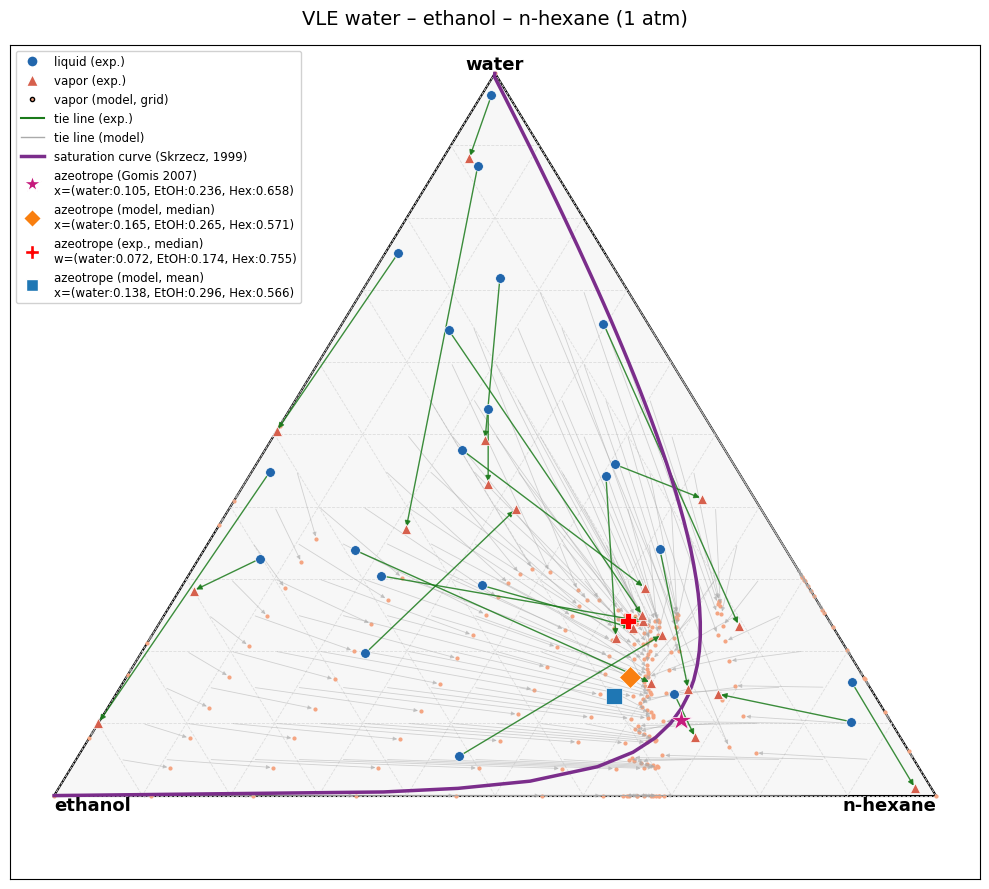

In [114]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from nrtl import bubbleP_nrtl, nrtl
from scipy.optimize import brentq
import matplotlib.pyplot as plt

w_az_exp_str   = "w=(water:0.072, EtOH:0.174, Hex:0.755)"
w_az_lit_str   = "x=(water:0.105, EtOH:0.236, Hex:0.658)"
w_az_mean_str  = "x=(water:0.138, EtOH:0.296, Hex:0.566)"
w_az_model_str = f"x=(water:{x_az_model[0]:.3f}, EtOH:{x_az_model[1]:.3f}, Hex:{x_az_model[2]:.3f})"

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(10, 9)
fig.patch.set_facecolor('white')

tax.boundary(linewidth=1.5)
tax.gridlines(multiple=0.1, color="#dddddd", linewidth=0.6, ls="--")

ax = tax.get_axes()
ax.set_facecolor('white')

# вершины
tax.annotate("n-hexane", (1, 0, 0), ha="right",  va="top",    fontsize=13, fontweight='bold')
tax.annotate("water",    (0, 1, 0), ha="center", va="bottom", fontsize=13, fontweight='bold')
tax.annotate("ethanol",  (0, 0, 1), ha="left",   va="top",    fontsize=13, fontweight='bold')

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", **kwargs))

# saturation curve
sat_curve_pts = [
    (0.0000, 2.3e-6), (0.3709, 0.0050), (0.4530, 0.0100), (0.5299, 0.0200),
    (0.5963, 0.0400), (0.6265, 0.0600), (0.6418, 0.0800), (0.6490, 0.1000),
    (0.6510, 0.1200), (0.6495, 0.1400), (0.6454, 0.1600), (0.6393, 0.1800),
    (0.6317, 0.2000), (0.6228, 0.2200), (0.6128, 0.2400), (0.6020, 0.2600),
    (0.5904, 0.2800), (0.5781, 0.3000), (0.5653, 0.3200), (0.5521, 0.3400),
    (0.5383, 0.3600), (0.5242, 0.3800), (0.5097, 0.4000), (0.4950, 0.4200),
    (0.4799, 0.4400), (0.4646, 0.4600), (0.4490, 0.4800), (0.4332, 0.5000),
    (0.4172, 0.5200), (0.4010, 0.5400), (0.3847, 0.5600), (0.3682, 0.5800),
    (0.3515, 0.6000), (0.3347, 0.6200), (0.3178, 0.6400), (0.3008, 0.6600),
    (0.2836, 0.6800), (0.2663, 0.7000), (0.2489, 0.7200), (0.2314, 0.7400),
    (0.2139, 0.7600), (0.1962, 0.7800), (0.1785, 0.8000), (0.1607, 0.8200),
    (0.1428, 0.8400), (0.1248, 0.8600), (0.1068, 0.8800), (0.0887, 0.9000),
    (0.0705, 0.9200), (0.0523, 0.9400), (0.0340, 0.9600), (0.0157, 0.9800),
    (0.0065, 0.9900), (0.0019, 0.9950), (0.0000, 0.99953),
]
sat_pts_ternary = [(x_eth, x_hex, 1-x_eth-x_hex)
                   for x_eth, x_hex in sat_curve_pts
                   if 1-x_eth-x_hex >= 0]
tax.plot(sat_pts_ternary, linewidth=2.5, color="#7B2D8B",
         marker=None, zorder=4, linestyle="-")

# сетка стрелок
for item in grid_results:
    if item is None:
        continue
    x, xv = item
    pL = (x[2],  x[0],  x[1])
    pV = (xv[2], xv[0], xv[1])
    tax.plot([pV], marker=".", color="#f4a582", markersize=4, zorder=2)
    draw_arrow(pL, pV, color="#aaaaaa", linewidth=0.6,
               mutation_scale=6, alpha=0.5,
               connectionstyle="arc3,rad=0.")

# подписи областей
def annotate_region(pt, text, color):
    x0, y0 = project_point(pt)
    ax.text(x0, y0, text, ha='center', va='center',
            fontsize=9, color=color, alpha=0.7, fontstyle='italic')

# экспериментальные точки
for xL, xV in zip(exp_xL, exp_xV):
    pL = (xL[2], xL[0], xL[1])
    pV = (xV[2], xV[0], xV[1])
    tax.plot([pL], marker="o", color="#2166ac", markersize=7,
             markeredgecolor="white", markeredgewidth=0.5, zorder=6)
    tax.plot([pV], marker="^", color="#d6604d", markersize=7,
             markeredgecolor="white", markeredgewidth=0.5, zorder=6)
    draw_arrow(pL, pV, color="#1a7a1a", linewidth=1.0,
               mutation_scale=8, alpha=0.85,
               connectionstyle="arc3,rad=0.")

# азеотроп литература
x_az_lit = np.array([0.105, 0.236, 0.658])
p_az_lit  = (x_az_lit[2], x_az_lit[0], x_az_lit[1])
tax.plot([p_az_lit], marker="*", color="#c51b7d", markersize=16, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

# азеотроп модель медиана
p_az_model = (x_az_model[2], x_az_model[0], x_az_model[1])
tax.plot([p_az_model], marker="D", color="#f97f0f", markersize=11, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

# азеотроп эксп медиана
x_az_exp_pt = np.array([0.2414, 0.2281, 0.5305])
p_az_exp    = (x_az_exp_pt[2], x_az_exp_pt[0], x_az_exp_pt[1])
tax.plot([p_az_exp], marker="P", color="#ff0000", markersize=12, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

# азеотроп модель среднее
x_az_mean = np.array([0.1384, 0.2958, 0.5658])
p_az_mean  = (x_az_mean[2], x_az_mean[0], x_az_mean[1])
tax.plot([p_az_mean], marker="s", color="#1f77b4", markersize=11, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

legend_elements = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="#2166ac",
           markersize=8, markeredgecolor="white", label="liquid (exp.)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="#d6604d",
           markersize=8, markeredgecolor="white", label="vapor (exp.)"),
    Line2D([0],[0], marker=".", color="none", markerfacecolor="#f4a582",
           markersize=6, label="vapor (model, grid)"),
    Line2D([0],[0], color="#1a7a1a", lw=1.5, label="tie line (exp.)"),
    Line2D([0],[0], color="#aaaaaa", lw=1.0, label="tie line (model)"),
    Line2D([0],[0], color="#7B2D8B", lw=2.5, label="saturation curve (Skrzecz, 1999)"),
    Line2D([0],[0], marker="*", color="none", markerfacecolor="#c51b7d",
           markersize=13, markeredgecolor="white",
           label=f"azeotrope (Gomis 2007)\n{w_az_lit_str}"),
    Line2D([0],[0], marker="D", color="none", markerfacecolor="#f97f0f",
           markersize=9, markeredgecolor="white",
           label=f"azeotrope (model, median)\n{w_az_model_str}"),
    Line2D([0],[0], marker="P", color="none", markerfacecolor="#ff0000",
           markersize=10, markeredgecolor="white",
           label=f"azeotrope (exp., median)\n{w_az_exp_str}"),
    Line2D([0],[0], marker="s", color="none", markerfacecolor="#1f77b4",
           markersize=9, markeredgecolor="white",
           label=f"azeotrope (model, mean)\n{w_az_mean_str}"),
]
ax.legend(handles=legend_elements, loc="upper left",
          frameon=True, fontsize=8.5, framealpha=0.9,
          edgecolor="#cccccc")

tax.clear_matplotlib_ticks()
plt.title("VLE water – ethanol – n-hexane (1 atm)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [85]:
import ternary
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.cm as cm
import numpy as np
from matplotlib.lines import Line2D
from nrtl import nrtl
from scipy.optimize import brentq

def bubbleT_nrtl(P, x, alpha, params):
    def residual(T):
        Psat = get_Psat(T)
        tau = build_tau(params, T)
        gamma = nrtl(alpha, tau, T, x)
        return np.sum(gamma * x * Psat) - P
    try:
        T_bub = brentq(residual, 280.0, 500.0)
    except Exception:
        return None, None
    Psat = get_Psat(T_bub)
    tau = build_tau(params, T_bub)
    gamma = nrtl(alpha, tau, T_bub, x)
    xv = gamma * x * Psat / P
    xv = xv / xv.sum()
    return T_bub, xv

P_atm = 101325.0

# мелкая сетка для heatmap
step = 0.02
hm_points = []
hm_temps  = []

for i in range(int(1/step) + 1):
    for j in range(int(1/step) + 1 - i):
        x1 = i * step   # вода
        x2 = j * step   # этанол
        x3 = 1.0 - x1 - x2  # гексан
        if x3 < 0 or x3 > 1:
            continue
        x = np.array([x1, x2, x3])
        T_bub, _ = bubbleT_nrtl(P_atm, x, model3.alpha, model3.params)
        if T_bub is not None:
            hm_points.append((x1, x2, x3))
            hm_temps.append(T_bub)

hm_points = np.array(hm_points)
hm_temps  = np.array(hm_temps)
print(f"Точек: {len(hm_points)}, T: {hm_temps.min():.1f}–{hm_temps.max():.1f} K")

# фильтруй физически невозможные точки
# вода кипит при 100°C, гексан при 69°C, этанол при 78°C
# минимум системы ~56°C (азеотроп этанол-гексан)
mask = (hm_temps > 328.0) & (hm_temps < 375.0)
hm_points_f = hm_points[mask]
hm_temps_f  = hm_temps[mask]
print(f"После фильтра: {mask.sum()} точек, T: {hm_temps_f.min():.1f}–{hm_temps_f.max():.1f} K")

Точек: 1143, T: 287.6–373.1 K
После фильтра: 1126 точек, T: 329.9–373.1 K


Точек для heatmap: 1055, T: 57.7–82.6 °C


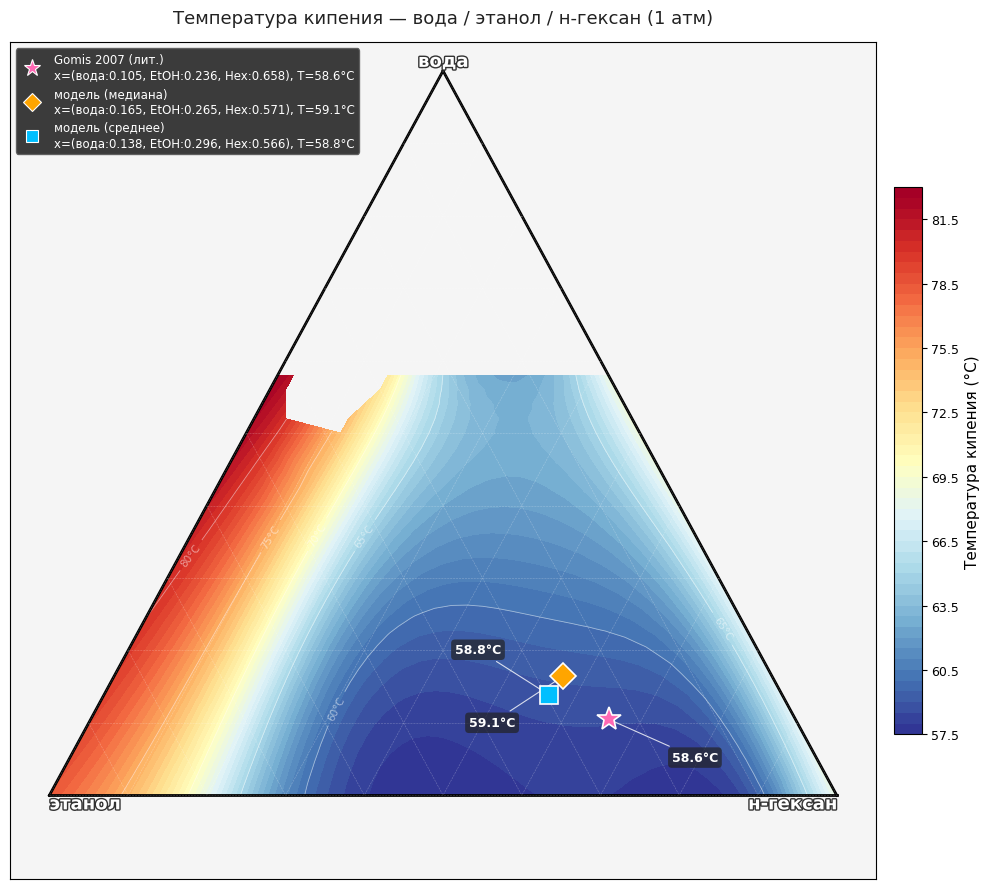

In [93]:
from ternary.helpers import project_point
import matplotlib.tri as mtri
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# маска: убираем артефакты и водо-богатые области
mask_final = mask & (hm_points[:, 0] < 0.60)
hm_pts = hm_points[mask_final]
hm_t   = hm_temps[mask_final] - 273.15

print(f"Точек для heatmap: {mask_final.sum()}, T: {hm_t.min():.1f}–{hm_t.max():.1f} °C")

# проекция в 2D
cart = np.array([project_point((x[2], x[0], x[1])) for x in hm_pts])
xs, ys = cart[:, 0], cart[:, 1]

triang = mtri.Triangulation(xs, ys)

# убираем артефактные треугольники (слишком длинные рёбра)
xmid = xs[triang.triangles].mean(axis=1)
ymid = ys[triang.triangles].mean(axis=1)
mask_tri = np.zeros(len(triang.triangles), dtype=bool)
for k, tri_idx in enumerate(triang.triangles):
    pts = cart[tri_idx]
    max_edge = max(
        np.linalg.norm(pts[0]-pts[1]),
        np.linalg.norm(pts[1]-pts[2]),
        np.linalg.norm(pts[0]-pts[2])
    )
    if max_edge > 0.08:
        mask_tri[k] = True
triang.set_mask(mask_tri)

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(10, 9)
fig.patch.set_facecolor('white')
ax = tax.get_axes()
ax.set_facecolor('#f5f5f5')

cmap = cm.RdYlBu_r
norm = mcolors.Normalize(vmin=hm_t.min(), vmax=hm_t.max())

# заливка
tcf = ax.tricontourf(triang, hm_t, levels=50, cmap=cmap, norm=norm, zorder=1)

# изолинии
contour_levels = np.arange(np.ceil(hm_t.min()/5)*5,
                            np.floor(hm_t.max()/5)*5 + 1, 5)
tc = ax.tricontour(triang, hm_t, levels=contour_levels,
                   colors='white', linewidths=0.6, alpha=0.5, zorder=2)
ax.clabel(tc, fmt='%.0f°C', fontsize=7.5, colors='white',
          inline=True, inline_spacing=3)

# colorbar
cbar = fig.colorbar(tcf, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('Температура кипения (°C)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# граница
tax.boundary(linewidth=2.0)
tax.gridlines(multiple=0.1, color="white", linewidth=0.4, ls="--", alpha=0.3)

# подписи вершин
for txt, pos, ha, va in [
    ("н-гексан", (1,0,0), "right",  "top"),
    ("вода",     (0,1,0), "center", "bottom"),
    ("этанол",   (0,0,1), "left",   "top"),
]:
    tax.annotate(txt, pos, ha=ha, va=va, fontsize=13,
                 fontweight='bold', color='white',
                 path_effects=[
                     __import__('matplotlib.patheffects', fromlist=['withStroke'])
                     .withStroke(linewidth=2, foreground='#333333')
                 ])

# азеотропы
azs = [
    (np.array([0.105,  0.236,  0.658]),  "*", "#ff69b4", 18, "Gomis 2007 (лит.)"),
    (np.array([0.1646, 0.2648, 0.5705]), "D", "#ffa500", 13, "модель (медиана)"),
    (np.array([0.1384, 0.2958, 0.5658]), "s", "#00bfff", 13, "модель (среднее)"),
]

legend_elements = []
offsets = [(0.08, -0.05), (-0.12, -0.06), (-0.12, 0.05)]

for (x_az, marker, color, ms, label), offset in zip(azs, offsets):
    p = (x_az[2], x_az[0], x_az[1])
    T_az, _ = bubbleT_nrtl(P_atm, x_az, model3.alpha, model3.params)
    t_az = T_az - 273.15 if T_az else None

    tax.plot([p], marker=marker, color=color, markersize=ms, zorder=7,
             markeredgecolor='white', markeredgewidth=1.2)

    cx, cy = project_point(p)
    if t_az:
        ax.annotate(f"{t_az:.1f}°C",
                    xy=(cx, cy),
                    xytext=(cx + offset[0], cy + offset[1]),
                    fontsize=9, color='white', fontweight='bold',
                    arrowprops=dict(arrowstyle="-", color='white',
                                    linewidth=0.8, alpha=0.8),
                    bbox=dict(boxstyle='round,pad=0.3', fc='#222222',
                              alpha=0.7, ec='none'))

    legend_elements.append(
        Line2D([0],[0], marker=marker, color="none",
               markerfacecolor=color, markersize=ms*0.7,
               markeredgecolor='white', markeredgewidth=0.8,
               label=f"{label}\nx=(вода:{x_az[0]:.3f}, EtOH:{x_az[1]:.3f}, Hex:{x_az[2]:.3f})"
                     + (f", T={t_az:.1f}°C" if t_az else ""))
    )

ax.legend(handles=legend_elements, loc="upper left",
          frameon=True, fontsize=8.5, framealpha=0.85,
          facecolor="#1a1a1a", edgecolor="#555555",
          labelcolor="white")

tax.clear_matplotlib_ticks()
plt.title("Температура кипения — вода / этанол / н-гексан (1 атм)",
          fontsize=13, pad=14, color='#222222')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import brentq

for x in test_points:
    def residual(T):
        Psat = get_PsatT)
        tau = build_tau(model3.params, T)
        gamma = nrtl(model3.alpha, tau, T, x)
        return np.sum(gamma * x * Psat) - P_atm
    
    temps = np.linspace(330, 480, 20)
    vals = [residual(T) for T in temps]
    print(f"x={x}  f(330)={vals[0]:.1f}  f(480)={vals[-1]:.1f}  "
          f"min={min(vals):.1f}  max={max(vals):.1f}")

x=[0.8 0.1 0.1]  f(330)=17501.1  f(480)=970778.8  min=7324.1  max=970778.8
x=[0.7  0.15 0.15]  f(330)=1198.4  f(480)=635741.2  min=1198.4  max=635741.2
x=[0.6 0.2 0.2]  f(330)=-6026.1  f(480)=419501.5  min=-6026.1  max=419501.5
x=[0.9  0.05 0.05]  f(330)=39667.5  f(480)=1376353.6  min=616.1  max=1376353.6


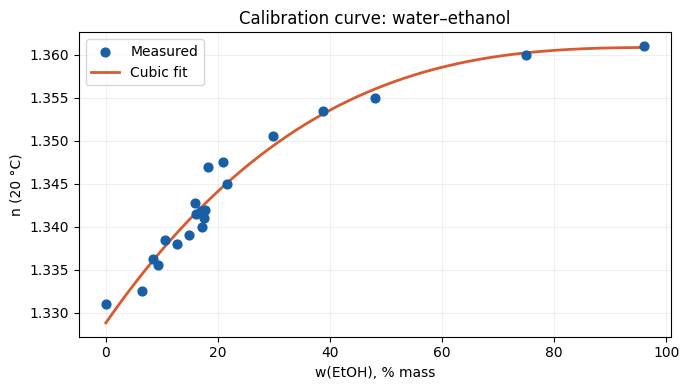

Coefficients (highest degree first): [ 2.94710642e-08 -9.09685008e-06  9.35401258e-04  1.32881247e+00]


In [94]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
    [0, 1.3310], [6.44, 1.3325], [8.40, 1.3362], [9.36, 1.3355],
    [10.55, 1.3385], [12.72, 1.3380], [14.91, 1.3390], [15.84, 1.3427],
    [16.07, 1.3415], [17.06, 1.3418], [17.12, 1.3400], [17.45, 1.3410],
    [17.76, 1.3420], [18.26, 1.3470], [20.91, 1.3475], [21.57, 1.3450],
    [29.86, 1.3505], [38.67, 1.3535], [48.00, 1.3550], [74.88, 1.3600],
    [96.00, 1.3610]
])

w, n = data[:, 0], data[:, 1]
coeffs = np.polyfit(w, n, 3)
w_fit = np.linspace(0, 96, 300)
n_fit = np.polyval(coeffs, w_fit)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(w, n, color='#185FA5', zorder=3, label='Measured', s=40)
ax.plot(w_fit, n_fit, color='#D85A30', linewidth=2, label='Cubic fit')

ax.set_xlabel('w(EtOH), % mass')
ax.set_ylabel('n (20 °C)')
ax.set_title('Calibration curve: water–ethanol')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Coefficients (highest degree first):", coeffs)

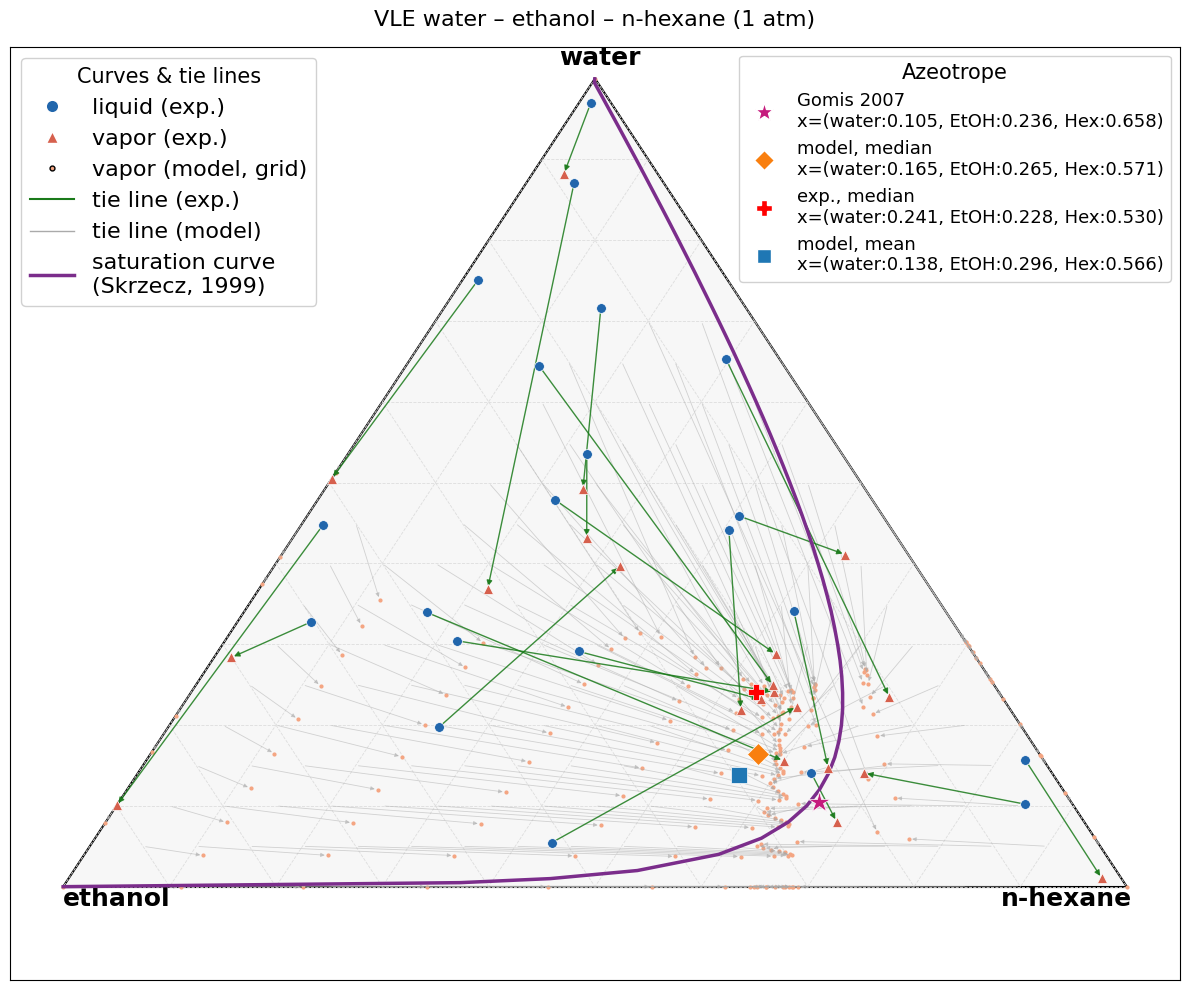

In [121]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from nrtl import bubbleP_nrtl, nrtl
from scipy.optimize import brentq
import matplotlib.pyplot as plt

x_az_exp_pt = np.array([0.2414, 0.2281, 0.5305])
x_az_mean   = np.array([0.1384, 0.2958, 0.5658])

w_az_exp_str   = f"x=(water:{x_az_exp_pt[0]:.3f}, EtOH:{x_az_exp_pt[1]:.3f}, Hex:{x_az_exp_pt[2]:.3f})"
w_az_lit_str   = "x=(water:0.105, EtOH:0.236, Hex:0.658)"
w_az_mean_str  = f"x=(water:{x_az_mean[0]:.3f}, EtOH:{x_az_mean[1]:.3f}, Hex:{x_az_mean[2]:.3f})"
w_az_model_str = f"x=(water:{x_az_model[0]:.3f}, EtOH:{x_az_model[1]:.3f}, Hex:{x_az_model[2]:.3f})"

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(12, 10)
fig.patch.set_facecolor('white')

tax.boundary(linewidth=1.5)
tax.gridlines(multiple=0.1, color="#dddddd", linewidth=0.6, ls="--")

ax = tax.get_axes()
ax.set_facecolor('white')

# вершины
tax.annotate("n-hexane", (1.005, 0, 0), ha="right",  va="top",    fontsize=18, fontweight='bold')
tax.annotate("water",    (0, 1.01, 0), ha="center", va="bottom", fontsize=18, fontweight='bold')
tax.annotate("ethanol",  (0, 0, 1.01), ha="left",   va="top",    fontsize=18, fontweight='bold')

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", **kwargs))

# saturation curve
sat_curve_pts = [
    (0.0000, 2.3e-6), (0.3709, 0.0050), (0.4530, 0.0100), (0.5299, 0.0200),
    (0.5963, 0.0400), (0.6265, 0.0600), (0.6418, 0.0800), (0.6490, 0.1000),
    (0.6510, 0.1200), (0.6495, 0.1400), (0.6454, 0.1600), (0.6393, 0.1800),
    (0.6317, 0.2000), (0.6228, 0.2200), (0.6128, 0.2400), (0.6020, 0.2600),
    (0.5904, 0.2800), (0.5781, 0.3000), (0.5653, 0.3200), (0.5521, 0.3400),
    (0.5383, 0.3600), (0.5242, 0.3800), (0.5097, 0.4000), (0.4950, 0.4200),
    (0.4799, 0.4400), (0.4646, 0.4600), (0.4490, 0.4800), (0.4332, 0.5000),
    (0.4172, 0.5200), (0.4010, 0.5400), (0.3847, 0.5600), (0.3682, 0.5800),
    (0.3515, 0.6000), (0.3347, 0.6200), (0.3178, 0.6400), (0.3008, 0.6600),
    (0.2836, 0.6800), (0.2663, 0.7000), (0.2489, 0.7200), (0.2314, 0.7400),
    (0.2139, 0.7600), (0.1962, 0.7800), (0.1785, 0.8000), (0.1607, 0.8200),
    (0.1428, 0.8400), (0.1248, 0.8600), (0.1068, 0.8800), (0.0887, 0.9000),
    (0.0705, 0.9200), (0.0523, 0.9400), (0.0340, 0.9600), (0.0157, 0.9800),
    (0.0065, 0.9900), (0.0019, 0.9950), (0.0000, 0.99953),
]
sat_pts_ternary = [(x_eth, x_hex, 1-x_eth-x_hex)
                   for x_eth, x_hex in sat_curve_pts
                   if 1-x_eth-x_hex >= 0]
tax.plot(sat_pts_ternary, linewidth=2.5, color="#7B2D8B",
         marker=None, zorder=4, linestyle="-")

# сетка стрелок
for item in grid_results:
    if item is None:
        continue
    x, xv = item
    pL = (x[2],  x[0],  x[1])
    pV = (xv[2], xv[0], xv[1])
    tax.plot([pV], marker=".", color="#f4a582", markersize=4, zorder=2)
    draw_arrow(pL, pV, color="#aaaaaa", linewidth=0.6,
               mutation_scale=6, alpha=0.5,
               connectionstyle="arc3,rad=0.")

# подписи областей
def annotate_region(pt, text, color):
    x0, y0 = project_point(pt)
    ax.text(x0, y0, text, ha='center', va='center',
            fontsize=12, color=color, alpha=0.7, fontstyle='italic')

# экспериментальные точки
for xL, xV in zip(exp_xL, exp_xV):
    pL = (xL[2], xL[0], xL[1])
    pV = (xV[2], xV[0], xV[1])
    tax.plot([pL], marker="o", color="#2166ac", markersize=7,
             markeredgecolor="white", markeredgewidth=0.5, zorder=6)
    tax.plot([pV], marker="^", color="#d6604d", markersize=7,
             markeredgecolor="white", markeredgewidth=0.5, zorder=6)
    draw_arrow(pL, pV, color="#1a7a1a", linewidth=1.0,
               mutation_scale=8, alpha=0.85,
               connectionstyle="arc3,rad=0.")

# азеотроп литература
x_az_lit = np.array([0.105, 0.236, 0.658])
p_az_lit  = (x_az_lit[2], x_az_lit[0], x_az_lit[1])
tax.plot([p_az_lit], marker="*", color="#c51b7d", markersize=16, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

# азеотроп модель медиана
p_az_model = (x_az_model[2], x_az_model[0], x_az_model[1])
tax.plot([p_az_model], marker="D", color="#f97f0f", markersize=11, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

# азеотроп эксп медиана
p_az_exp = (x_az_exp_pt[2], x_az_exp_pt[0], x_az_exp_pt[1])
tax.plot([p_az_exp], marker="P", color="#ff0000", markersize=12, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

# азеотроп модель среднее
p_az_mean = (x_az_mean[2], x_az_mean[0], x_az_mean[1])
tax.plot([p_az_mean], marker="s", color="#1f77b4", markersize=11, zorder=7,
         markeredgecolor="white", markeredgewidth=0.5)

# ── Легенда 1: линии/кривые — слева сверху ──────────────────────────────────
legend_lines = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="#2166ac",
           markersize=9, markeredgecolor="white", label="liquid (exp.)"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="#d6604d",
           markersize=9, markeredgecolor="white", label="vapor (exp.)"),
    Line2D([0],[0], marker=".", color="none", markerfacecolor="#f4a582",
           markersize=7, label="vapor (model, grid)"),
    Line2D([0],[0], color="#1a7a1a", lw=1.5, label="tie line (exp.)"),
    Line2D([0],[0], color="#aaaaaa", lw=1.0, label="tie line (model)"),
    Line2D([0],[0], color="#7B2D8B", lw=2.5,
           label="saturation curve\n(Skrzecz, 1999)"),
]
leg1 = ax.legend(handles=legend_lines, loc="upper left",
                 frameon=True, fontsize=16, framealpha=0.9,
                 edgecolor="#cccccc", title="Curves & tie lines",
                 title_fontsize=15)
ax.add_artist(leg1)

# ── Легенда 2: азеотропные точки — справа сверху ────────────────────────────
legend_azeotropes = [
    Line2D([0],[0], marker="*", color="none", markerfacecolor="#c51b7d",
           markersize=14, markeredgecolor="white",
           label=f"Gomis 2007\n{w_az_lit_str}"),
    Line2D([0],[0], marker="D", color="none", markerfacecolor="#f97f0f",
           markersize=10, markeredgecolor="white",
           label=f"model, median\n{w_az_model_str}"),
    Line2D([0],[0], marker="P", color="none", markerfacecolor="#ff0000",
           markersize=11, markeredgecolor="white",
           label=f"exp., median\n{w_az_exp_str}"),
    Line2D([0],[0], marker="s", color="none", markerfacecolor="#1f77b4",
           markersize=10, markeredgecolor="white",
           label=f"model, mean\n{w_az_mean_str}"),
]
leg2 = ax.legend(handles=legend_azeotropes, loc="upper right",
                 frameon=True, fontsize=13, framealpha=0.9,
                 edgecolor="#cccccc", title="Azeotrope",
                 title_fontsize=15)

tax.clear_matplotlib_ticks()
plt.title("VLE water – ethanol – n-hexane (1 atm)", fontsize=16, pad=15)
plt.tight_layout()
plt.show()